In [42]:
import torch
from pathlib import Path  
import numpy as np
import matplotlib.pyplot as plt
import gzip
import random
import vtk
from vtk.util import numpy_support as vtknp
import os



In [43]:
path_to_sand_database = Path("../data/lunar/generated")

In [51]:
# list files in the directory
files = list(path_to_sand_database.glob("*.pt.gz"))
print(files)



[PosixPath('../data/lunar/generated/lunar_rve_0009.pt.gz'), PosixPath('../data/lunar/generated/lunar_rve_0008.pt.gz'), PosixPath('../data/lunar/generated/lunar_rve_0004.pt.gz'), PosixPath('../data/lunar/generated/lunar_rve_0006.pt.gz'), PosixPath('../data/lunar/generated/lunar_rve_0002.pt.gz'), PosixPath('../data/lunar/generated/lunar_rve_0000.pt.gz'), PosixPath('../data/lunar/generated/lunar_rve_0007.pt.gz'), PosixPath('../data/lunar/generated/lunar_rve_0005.pt.gz'), PosixPath('../data/lunar/generated/lunar_rve_0001.pt.gz'), PosixPath('../data/lunar/generated/lunar_rve_0003.pt.gz')]


In [52]:
# open the first file
with gzip.open(files[2], "rb") as f:
    data = torch.load(f)
    


In [53]:
len(data)

10

In [56]:
#random voxel grid
voxel_grid = random.choice(data)

# show the shape of the voxel grid
print(voxel_grid.shape)





torch.Size([32, 64, 64])


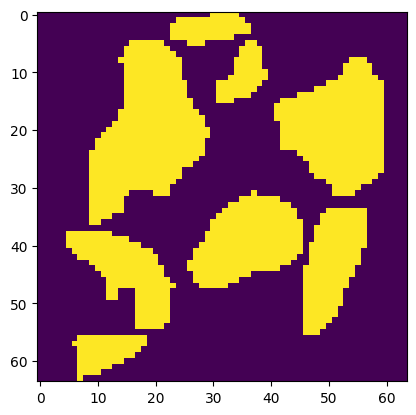

In [57]:
# plot the middle slice of the voxel grdid
plt.imshow(voxel_grid[voxel_grid.shape[0] // 2, :, :])

In [58]:
# # plot 3d voxel grid with a transparency of 50 pc
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# ax.voxels(voxel_grid, alpha=0.5)

# plt.show()

In [59]:
# export as vti file
# ensure NumPy array on CPU and correct dtype
voxel_grid = voxel_grid.numpy()
arr = np.ascontiguousarray(voxel_grid).astype(np.uint8)

# VTK expects dimensions as (x, y, z) and data in Fortran order
# Our tensor shape is (z, y, x) so we map dims accordingly and ravel in 'F' order
image_data = vtk.vtkImageData()
image_data.SetDimensions(int(arr.shape[2]), int(arr.shape[1]), int(arr.shape[0]))
image_data.SetSpacing(1.0, 1.0, 1.0)
image_data.SetOrigin(0.0, 0.0, 0.0)

vtk_array = vtknp.numpy_to_vtk(num_array=arr.ravel(order='C'), deep=True, array_type=vtk.VTK_UNSIGNED_CHAR)
vtk_array.SetName("scalars")
image_data.GetPointData().SetScalars(vtk_array)

# write .vti file
outfile = os.path.expanduser("~/Downloads/sand.vti")
writer = vtk.vtkXMLImageDataWriter()
writer.SetFileName(outfile)
writer.SetInputData(image_data)
writer.Write()

1